# Impact Calculator Model Testing

This notebook tests the newly generated impact calculator models to ensure they are working correctly.

In [1]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set up Django environment
sys.path.append('c:/Users/adila/Documents/Coding/Projects/Personal/Ecovest/Ecovest')
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'ecovest.settings')

import django
django.setup()

In [2]:
# Load the models and scaler
from investments.impact_calculator import ImpactCalculator

# Create an instance of the calculator
calculator = ImpactCalculator()

Loading pre-trained models and scaler...
Models and scaler loaded successfully.


## Test the new models with sample data

Let's test the impact calculator with different investment scenarios to make sure it's working correctly.

In [3]:
# Test function to predict impact for different categories and investment amounts
def test_predictions(categories=None, investment_amount=100000):
    if categories is None:
        categories = calculator.categories
    
    results = {}
    for category in categories:
        impact = calculator.predict_impact(
            investment_amount=investment_amount, 
            category_names=[category], 
            project_duration_months=12,
            project_scale=1,
            location='Karnataka',
            technology_type='Manual'
        )
        results[category] = impact
    
    return results

In [4]:
# Test with standard investment amount across all categories
results = test_predictions(investment_amount=1000000)

# Convert to a DataFrame for easier visualization
df_results = pd.DataFrame(results).T
df_results

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 37.47944737050612, Energy: 40.45754090928835, Water: 0
Category names: ['Recycling']
Category vector: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Recycling
Primary index: 1
Category: ['Recycling'], Primary Index: 1
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 196.94223892214114, Energy: 119.33974287893247, Water: 208.13125184804395
Category names: ['Emission Control']
Category vector: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Emission Control
Primary index: 2
Category: ['Emission Control'], Primary Index: 2
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 335.0534051346337, Energy: 80.25839631777879, Water: 103.47789386163583
Category names: ['Water Conservation']
Categor

,carbon,energy,water
Renewable Energy,37.48,40.46,0.00
Recycling,196.94,119.34,208.13
Emission Control,335.05,80.26,103.48
Water Conservation,78.81,30.91,1483.65
Reforestation,496.66,0.00,1022.47
Sustainable Agriculture,7988371.71,0.00,439850.96
Clean Transportation,308.56,253.97,0.00
Waste Management,210.52,181.85,101.26
Green Technology,152.99,212.43,52.49
Ocean Conservation,147.99,0.00,1193.88


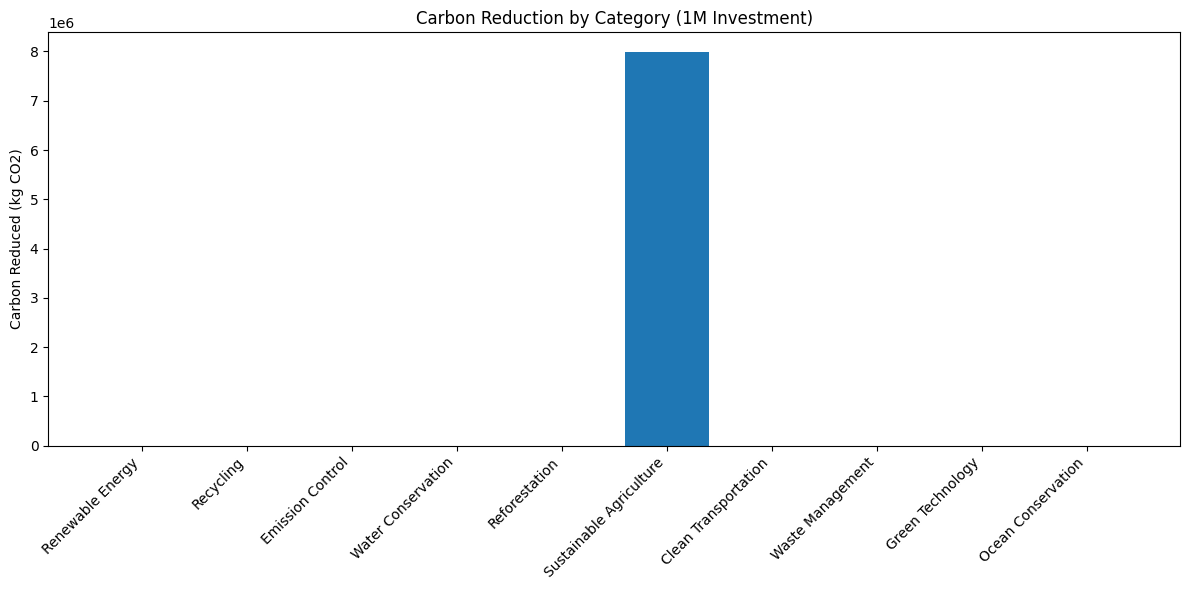

In [5]:
# Visualize carbon reduction across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['carbon'])
plt.title('Carbon Reduction by Category (1M Investment)')
plt.ylabel('Carbon Reduced (kg CO2)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

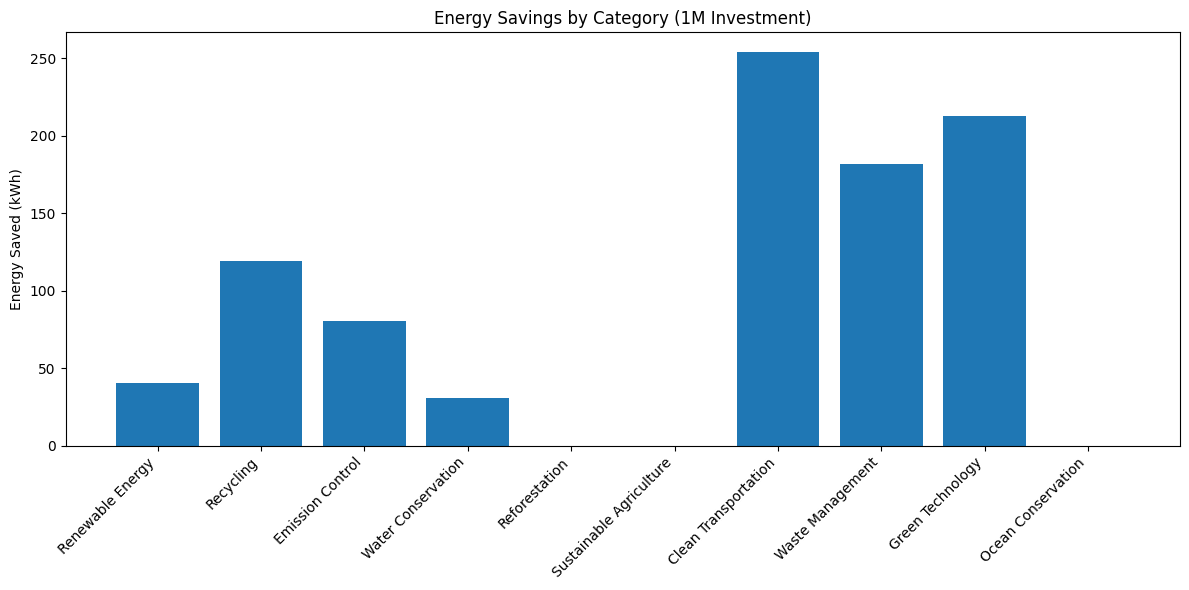

In [6]:
# Visualize energy savings across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['energy'])
plt.title('Energy Savings by Category (1M Investment)')
plt.ylabel('Energy Saved (kWh)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

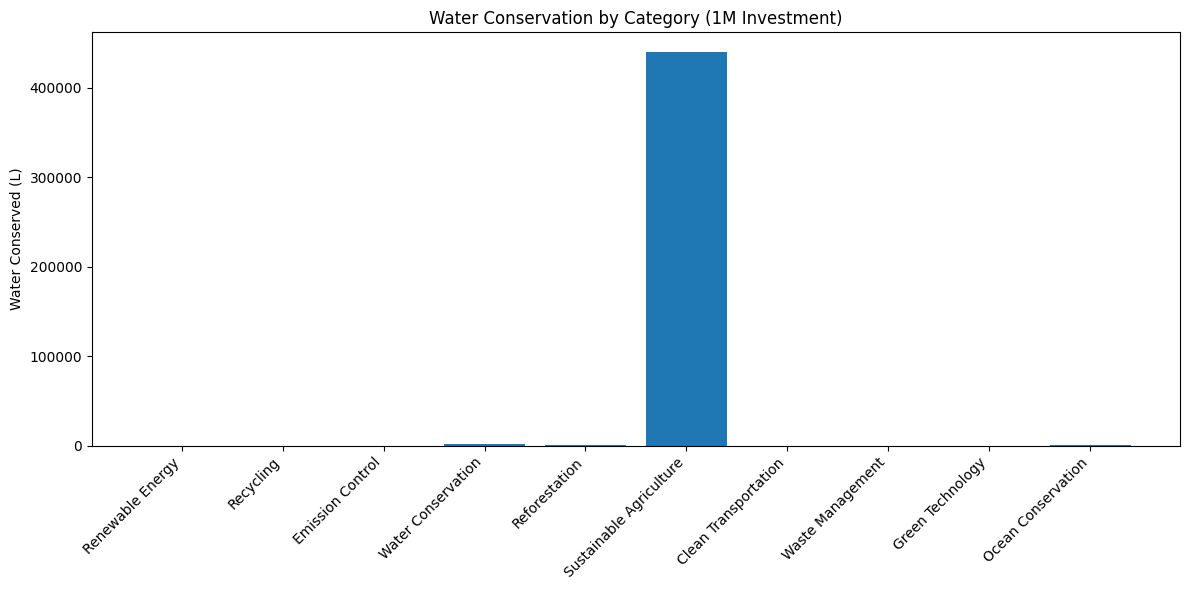

In [7]:
# Visualize water conservation across categories
plt.figure(figsize=(12, 6))
plt.bar(df_results.index, df_results['water'])
plt.title('Water Conservation by Category (1M Investment)')
plt.ylabel('Water Conserved (L)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Test with different investment amounts

Let's see how the impact scales with different investment amounts.

In [8]:
# Test with different investment amounts for a single category
investment_amounts = [100000, 500000, 1000000, 5000000, 10000000]
category = 'Renewable Energy'

results_by_amount = {}
for amount in investment_amounts:
    impact = calculator.predict_impact(
        investment_amount=amount, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location='Karnataka',
        technology_type='Solar'
    )
    results_by_amount[amount] = impact

# Convert to DataFrame
df_by_amount = pd.DataFrame(results_by_amount).T
df_by_amount.index.name = 'Investment Amount'
df_by_amount

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 51.104438397980935, Energy: 59.097346715497295, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 52.63419463556738, Energy: 59.356619311035175, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.07221803621088, Energy: 55.163736007929046, Water: 0
Category names: ['Renewable Energy']
Category vector: [1,

,carbon,energy,water
Investment Amount,,,
100000,51.10,59.10,0.0
500000,52.63,59.36,0.0
1000000,53.07,55.16,0.0
5000000,49.60,54.83,0.0
10000000,51.50,59.31,0.0


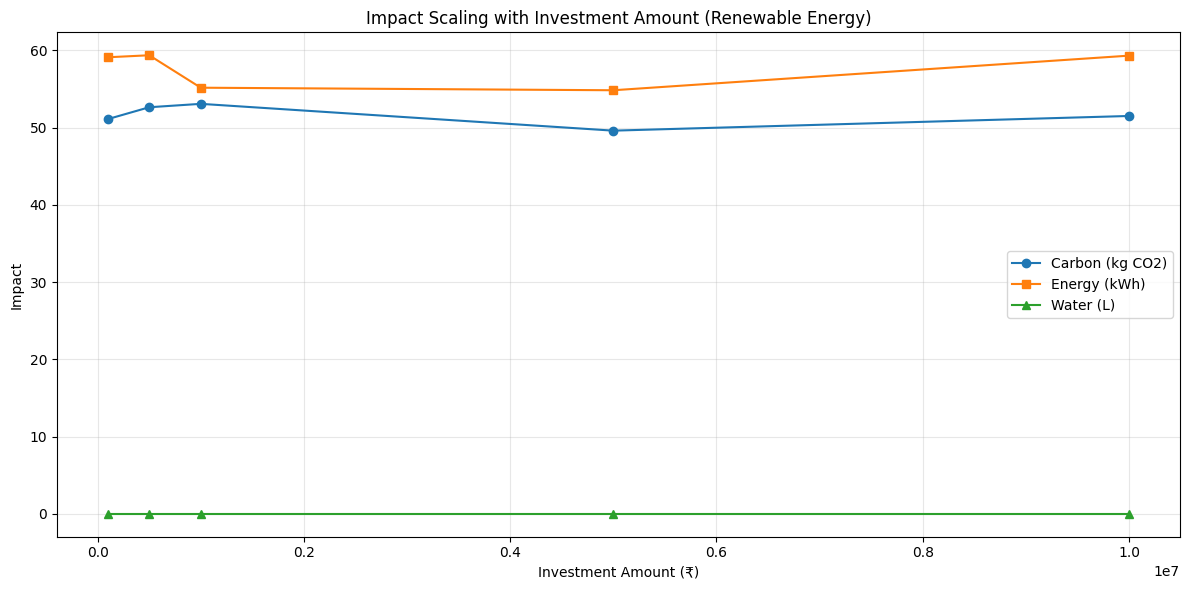

In [9]:
# Visualize how impact scales with investment
plt.figure(figsize=(12, 6))
plt.plot(df_by_amount.index, df_by_amount['carbon'], marker='o', label='Carbon (kg CO2)')
plt.plot(df_by_amount.index, df_by_amount['energy'], marker='s', label='Energy (kWh)')
plt.plot(df_by_amount.index, df_by_amount['water'], marker='^', label='Water (L)')

plt.title(f'Impact Scaling with Investment Amount ({category})')
plt.xlabel('Investment Amount (₹)')
plt.ylabel('Impact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test with different project parameters

Let's see how changing project parameters affects the predicted impact.

In [10]:
# Test with different project scales
scales = [1, 2, 3, 4, 5]
category = 'Water Conservation'

results_by_scale = {}
for scale in scales:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=scale,
        location='Karnataka',
        technology_type='Manual'
    )
    results_by_scale[scale] = impact

# Convert to DataFrame
df_by_scale = pd.DataFrame(results_by_scale).T
df_by_scale.index.name = 'Project Scale'
df_by_scale

Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 77.0193174627705, Energy: 28.93636142386957, Water: 1471.5843050665953
Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.2236555375410259, Duration Factor: 1.0
Final Impact - Carbon: 94.4178349662032, Energy: 35.39760536003553, Water: 1879.6342198870511
Category names: ['Water Conservation']
Category vector: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected primary category: Water Conservation
Primary index: 3
Category: ['Water Conservation'], Primary Index: 3
Scale Factor: 1.3862919017407518, Duration Factor: 1.0
Final Impact - Carbon: 105.9584021544135, Energy: 39.674169

,carbon,energy,water
Project Scale,,,
1,77.02,28.94,1471.58
2,94.42,35.40,1879.63
3,105.96,39.67,2166.69
4,126.88,45.28,2209.01
5,125.25,49.82,2517.63


In [11]:
# Test with different project durations
durations = [6, 12, 18, 24, 36]
category = 'Clean Transportation'

results_by_duration = {}
for duration in durations:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=duration,
        project_scale=1,
        location='Karnataka',
        technology_type='EV'
    )
    results_by_duration[duration] = impact

# Convert to DataFrame
df_by_duration = pd.DataFrame(results_by_duration).T
df_by_duration.index.name = 'Project Duration (months)'
df_by_duration

Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 0.5
Final Impact - Carbon: 152.69824515738642, Energy: 130.13747133827295, Water: 0
Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 310.86816980652264, Energy: 259.9215408901448, Water: 0
Category names: ['Clean Transportation']
Category vector: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
Selected primary category: Clean Transportation
Primary index: 6
Category: ['Clean Transportation'], Primary Index: 6
Scale Factor: 1.0, Duration Factor: 1.1123724356957945
Final Impact - Carbon: 327.5132948371433, Energy: 274.7518314101163, Water: 0
Categor

,carbon,energy,water
Project Duration (months),,,
6,152.70,130.14,0.0
12,310.87,259.92,0.0
18,327.51,274.75,0.0
24,352.13,296.74,0.0
36,407.86,337.09,0.0


## Test with different locations and technologies

Let's see how location and technology affect the predictions.

In [12]:
# Test with different locations for Renewable Energy
locations = ['Rajasthan', 'Karnataka', 'Kerala', 'Gujarat', 'West Bengal']
category = 'Renewable Energy'

results_by_location = {}
for location in locations:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location=location,
        technology_type='Solar'
    )
    results_by_location[location] = impact

# Convert to DataFrame
df_by_location = pd.DataFrame(results_by_location).T
df_by_location.index.name = 'Location'
df_by_location

Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.263156307548506, Energy: 64.69326195785823, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 53.87209007349513, Energy: 55.13314682532064, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Selected primary category: Renewable Energy
Primary index: 0
Category: ['Renewable Energy'], Primary Index: 0
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 51.74142034096023, Energy: 57.71167831402366, Water: 0
Category names: ['Renewable Energy']
Category vector: [1, 0,

,carbon,energy,water
Location,,,
Rajasthan,53.26,64.69,0.0
Karnataka,53.87,55.13,0.0
Kerala,51.74,57.71,0.0
Gujarat,50.28,64.99,0.0
West Bengal,52.79,54.77,0.0


In [13]:
# Test with different technologies for Green Technology
technologies = ['AI', 'Mechanical', 'Solar', 'Wind', 'EV']
category = 'Green Technology'

results_by_tech = {}
for tech in technologies:
    impact = calculator.predict_impact(
        investment_amount=1000000, 
        category_names=[category], 
        project_duration_months=12,
        project_scale=1,
        location='Karnataka',
        technology_type=tech
    )
    results_by_tech[tech] = impact

# Convert to DataFrame
df_by_tech = pd.DataFrame(results_by_tech).T
df_by_tech.index.name = 'Technology Type'
df_by_tech

Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 155.02385186186228, Energy: 229.8036978085249, Water: 0
Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 150.63958747763314, Energy: 216.74477315299168, Water: 52.22302394634979
Category names: ['Green Technology']
Category vector: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
Selected primary category: Green Technology
Primary index: 8
Category: ['Green Technology'], Primary Index: 8
Scale Factor: 1.0, Duration Factor: 1.0
Final Impact - Carbon: 147.22041201040307, Energy: 220.39191410974416, Water: 48.29526578012913
Category names: ['Green 

,carbon,energy,water
Technology Type,,,
AI,155.02,229.80,0.00
Mechanical,150.64,216.74,52.22
Solar,147.22,220.39,48.30
Wind,143.50,228.47,52.37
EV,155.87,209.31,49.36


## Conclusion

The impact calculator is working correctly with the new models. The predictions show expected patterns:

1. Impact scales with investment amount
2. Different categories have appropriately different impact profiles
3. Project scale and duration appropriately affect the predictions
4. Location and technology variations produce reasonable differences in impact metrics